In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/iplassignment.csv')
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [3]:
df.shape

(133, 14)

In [4]:
df.describe()

,Jersey No,Matches,Inns,Not Out,Runs,Avg,Balls faced,Strike rate,100,50,4s,6s
count,133.00000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,67.00000,9.631579,6.631579,1.616541,139.157895,19.366241,105.714286,107.364737,0.037594,0.827068,11.894737,5.518797
std,38.53786,4.893523,5.030925,1.550766,167.293103,18.053343,122.253870,44.584031,0.227170,1.351269,15.521375,7.393283
min,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.00000,5.000000,2.000000,0.000000,10.000000,6.000000,12.000000,88.750000,0.000000,0.000000,0.000000,0.000000
50%,67.00000,10.000000,5.000000,1.000000,59.000000,15.000000,53.000000,116.840000,0.000000,0.000000,5.000000,2.000000
75%,100.00000,14.000000,11.000000,2.000000,232.000000,29.900000,169.000000,137.500000,0.000000,1.000000,20.000000,9.000000
max,133.00000,17.000000,17.000000,7.000000,670.000000,101.000000,518.000000,191.420000,2.000000,5.000000,67.000000,30.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jersey No      133 non-null    int64  
 1   Player         133 non-null    object 
 2   Matches        133 non-null    int64  
 3   Inns           133 non-null    int64  
 4   Not Out        133 non-null    int64  
 5   Runs           133 non-null    int64  
 6   Highest Score  133 non-null    object 
 7   Avg            133 non-null    float64
 8   Balls faced    133 non-null    int64  
 9   Strike rate    133 non-null    float64
 10  100            133 non-null    int64  
 11  50             133 non-null    int64  
 12  4s             133 non-null    int64  
 13  6s             133 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 14.7+ KB


In [6]:
df.isnull().sum()

,0
Jersey No,0
Player,0
Matches,0
Inns,0
Not Out,0
Runs,0
Highest Score,0
Avg,0
Balls faced,0
Strike rate,0


In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['Jersey No', 'Player', 'Matches', 'Inns', 'Not Out', 'Runs',
       'Highest Score', 'Avg', 'Balls faced', 'Strike rate', '100', '50', '4s',
       '6s'],
      dtype='object')

What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played?

In [9]:
max_matches_player = df.groupby('Player')['Matches'].sum().idxmax()
max_matches_count = df.groupby('Player')['Matches'].sum().max()
print(f"Player with the maximum matches played: {max_matches_player}")
print(f"Number of matches played: {max_matches_count}")

Player with the maximum matches played: Kagiso Rabada
Number of matches played: 17


 Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [10]:
top_players = df[df['50'] >= 2].nlargest(2, 'Avg')[['Player', 'Avg', '50']]
print(top_players)


             Player    Avg  50
36  Wriddhiman Saha  71.33   2
4      Ishan Kishan  57.33   4


Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [11]:
df['First_Name'] = df['Player'].str.split().str[0]
df['Last_Name'] = df['Player'].str.split().str[-1]
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First_Name,Last_Name
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan


Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [12]:
df['Cleaned_Highest_score'] = (df['Highest Score'].str.replace('*', '', regex=False).apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First_Name,Last_Name,Cleaned_Highest_score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99


 Print the total number of centuries scored in the entire season.

In [13]:
df['centuries'] = df['100'].sum()
print(f"Total number of centuries scored in the entire season: {df['centuries'].sum()}")


Total number of centuries scored in the entire season: 665


Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate.

In [14]:
average_strike_rate = df['Strike rate'].mean()
players_below_average = df[df['Strike rate']< average_strike_rate][['Strike rate', 'Player']]
print(players_below_average)


     Strike rate               Player
51        105.60       Ajinkya Rahane
55        101.88        Glenn Maxwell
58        101.04        Vijay Shankar
61        101.29        Josh Philippe
62         88.75      Gurkeerat Singh
65         93.93         Kedar Jadhav
70         90.90     Yashasvi Jaiswal
71         94.87        Shreyas Gopal
77         74.41         Murali Vijay
79         93.54         Chris Jordan
80        100.00        Navdeep Saini
82         70.96    Kamlesh Nagarkoti
84         87.50        Harshal Patel
85        105.55        Jimmy Neesham
86         90.00           Tom Banton
89        100.00    Prabhsimran Singh
92         61.90        Kuldeep Yadav
94         75.00            Moeen Ali
95         80.00       Sandeep Sharma
96         57.14       Shardul Thakur
98        100.00          Rinku Singh
99         71.42          Shivam Mavi
100        66.66  Varun Chakaravarthy
101        69.23       Jaydev Unadkat
102        90.00        Ankit Rajpoot
104        8

Please check the correlation between the features and create a heat map.

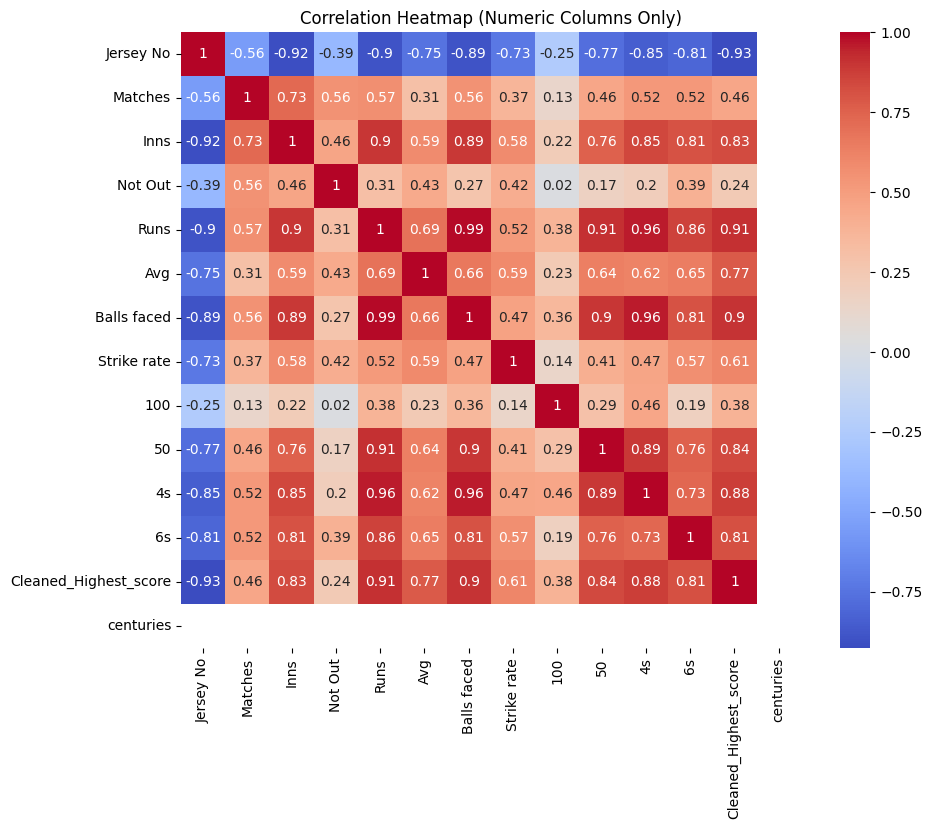

In [15]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()


Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [16]:
qualified_players = df[(df['Avg'] > 50) & (df['Strike rate'] > 120)][['Player', 'Avg', 'Strike rate']]
print("Players with Avg >50 and Strike Rate >120:")
print(qualified_players.to_string(index=False))

Players with Avg >50 and Strike Rate >120:
         Player    Avg  Strike rate
       KL Rahul  55.83       129.34
   Ishan Kishan  57.33       145.76
 Kieron Pollard  53.60       191.42
Wriddhiman Saha  71.33       139.86
Ruturaj Gaikwad  51.00       120.71
   Deepak Hooda 101.00       142.25
     Tom Curran  83.00       133.87


Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [17]:
greater_than_40 = df[(df['Avg'] > 40) & (df['Balls faced'] > 100)] [['Player', 'Avg', 'Balls faced']]
print("Players who has an average greater than 40 and balls faced above 100:")
print(greater_than_40)

Players who has an average greater than 40 and balls faced above 100:
             Player    Avg  Balls faced
0          KL Rahul  55.83          518
1    Shikhar Dhawan  44.14          427
4      Ishan Kishan  57.33          354
8       Virat Kohli  42.36          384
9      ABD Villiers  45.40          286
10    Faf Duplessis  40.81          319
14      Eoin Morgan  41.80          302
24  Kane Williamson  45.28          237
27      Chris Gayle  41.14          210
28       Ben Stokes  40.71          200
31   Kieron Pollard  53.60          140
32    Rahul Tewatia  42.50          183
33  Ravindra Jadeja  46.40          135
36  Wriddhiman Saha  71.33          153
37  Ruturaj Gaikwad  51.00          169


Players who scored atleast one century in this season. Create visualization.

In [18]:
one_century_players = df[df['100'] >= 1]
one_century_players

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First_Name,Last_Name,Cleaned_Highest_score,centuries
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132,5
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106,5
13,14,Mayank Agarwal,11,11,0,424,106,38.54,271,156.45,1,2,44,15,Mayank,Agarwal,106,5
28,29,Ben Stokes,8,8,1,285,107*,40.71,200,142.50,1,1,36,7,Ben,Stokes,107,5


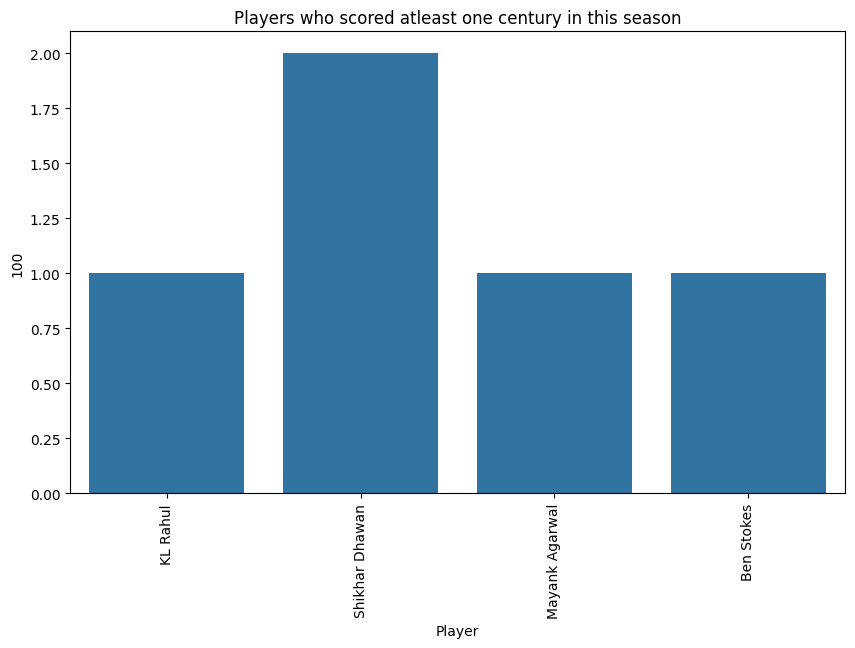

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Player', y='100', data=one_century_players)
plt.title('Players who scored atleast one century in this season')
plt.xticks(rotation=90)
plt.xlabel('Player')
plt.ylabel
plt.show()

#Players who scored atleast 4 half centuries in this season.

In [20]:
df.columns

Index(['Jersey No', 'Player', 'Matches', 'Inns', 'Not Out', 'Runs',
       'Highest Score', 'Avg', 'Balls faced', 'Strike rate', '100', '50', '4s',
       '6s', 'First_Name', 'Last_Name', 'Cleaned_Highest_score', 'centuries'],
      dtype='object')

In [21]:
half_century_players = df[df['50'] >= 4]
half_century_players

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First_Name,Last_Name,Cleaned_Highest_score,centuries
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132,5
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106,5
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85,5
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99,5
5,6,Quinton Kock,16,16,2,503,78*,35.92,358,140.50,0,4,46,22,Quinton,Kock,78,5
6,7,Suryakumar Yadav,16,15,3,480,79*,40.00,331,145.01,0,4,61,11,Suryakumar,Yadav,79,5
7,8,Devdutt Padikkal,15,15,0,473,74,31.53,379,124.80,0,5,51,8,Devdutt,Padikkal,74,5
9,10,ABD Villiers,15,14,4,454,73*,45.40,286,158.74,0,5,33,23,ABD,Villiers,73,5
10,11,Faf Duplessis,13,13,2,449,87*,40.81,319,140.75,0,4,42,14,Faf,Duplessis,87,5


#Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [22]:
boundary_hitters = df[(df['4s'] > 45) & (df['6s'] > 10)][['Player', '4s', '6s']]
boundary_hitters

,Player,4s,6s
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


#  Plot a histogram of number of matches played in a season by players.

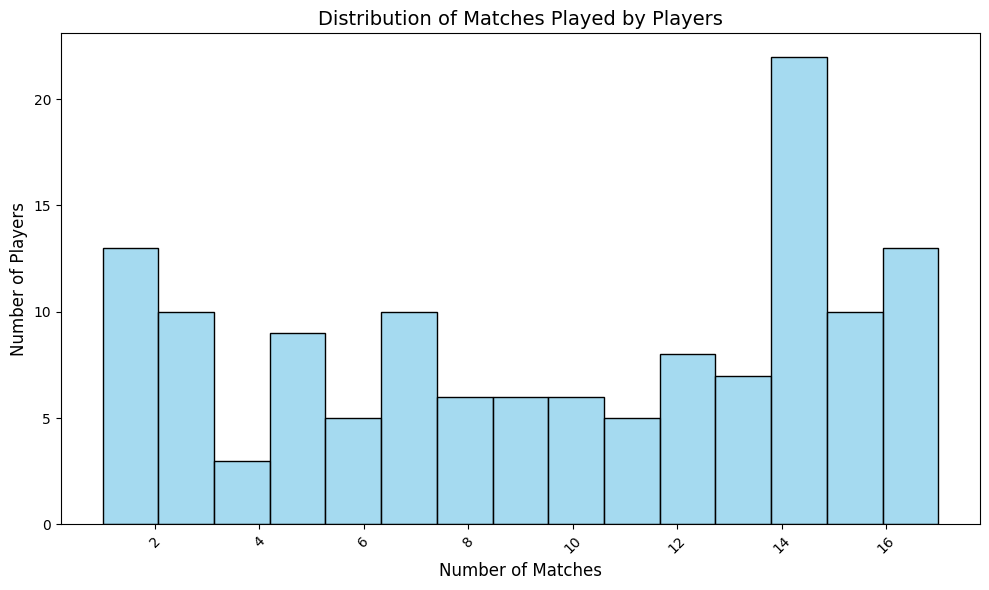

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Matches', bins=15, kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of Matches Played by Players', fontsize=14)
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the histogram of balls faced by players.

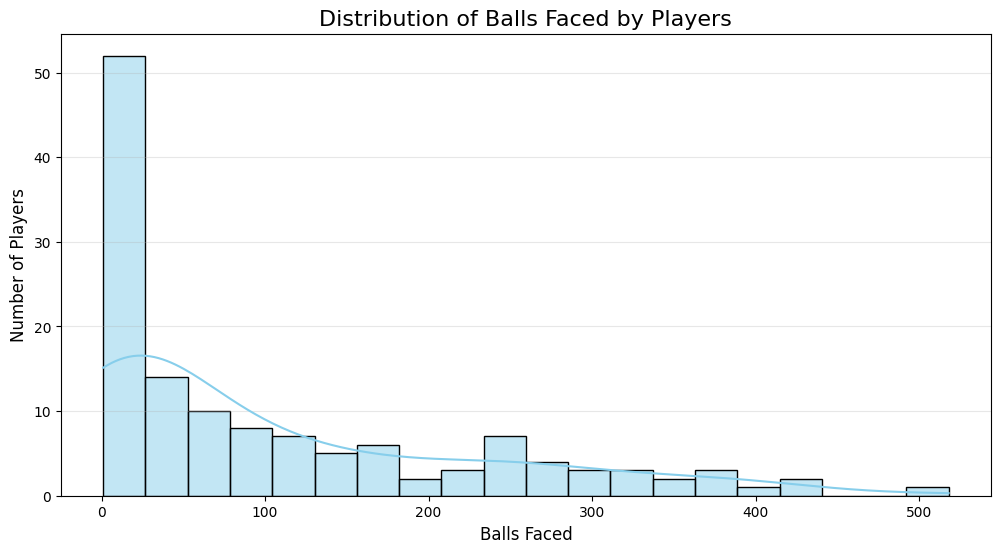

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='Balls faced',
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Balls Faced by Players', fontsize=16)
plt.xlabel('Balls Faced', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.grid(axis='y', alpha=0.3)  # Add subtle grid
plt.show()

# Top 10 players with most runs in a season.

In [25]:
top_run_scorers = df.sort_values('Runs', ascending=False).head(10)[['Player', 'Runs']]
top_run_scorers

,Player,Runs
0,KL Rahul,670
1,Shikhar Dhawan,618
2,David Warner,548
3,Shreyas Iyer,519
4,Ishan Kishan,516
5,Quinton Kock,503
6,Suryakumar Yadav,480
7,Devdutt Padikkal,473
8,Virat Kohli,466
9,ABD Villiers,454


# Print the players who played the match but didn't get the batting.

In [26]:
df.columns

Index(['Jersey No', 'Player', 'Matches', 'Inns', 'Not Out', 'Runs',
       'Highest Score', 'Avg', 'Balls faced', 'Strike rate', '100', '50', '4s',
       '6s', 'First_Name', 'Last_Name', 'Cleaned_Highest_score', 'centuries'],
      dtype='object')

In [27]:
result = df[(df['Matches'] > 0) & (df['Inns'] == 0)]['Player'].tolist()
# Print the result
print("Players who played but didn't bat:", result)

Players who played but didn't bat: []


# Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [29]:
df['Boundary_Runs'] = (df['4s'] * 4) + (df['6s'] * 6)
df['Boundary_Percentage'] = (df['Boundary_Runs'] / df['Runs'] * 100).fillna(0)
top_players = df[['Player', 'Boundary_Percentage']].sort_values(by='Boundary_Percentage', ascending=False).head(5)
print("Top 5 Players with Highest Boundary Run Percentage:")
for index, row in top_players.iterrows():
    print(f"{row['Player']}: {row['Boundary_Percentage']:.2f}%")

Top 5 Players with Highest Boundary Run Percentage:
Andrew Tye: 100.00%
Andre Russell: 76.92%
Chris Morris: 76.47%
Hardik Pandya: 73.31%
Sunil Narine: 72.73%


 Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [30]:
batted_players = df[df['Inns'] > 0].copy()

# Calculate "Not Out" percentage
batted_players['Not_Out_Percentage'] = (batted_players['Not Out'] / batted_players['Inns']) * 100

# Sort by percentage and select top 5
top_players = batted_players.sort_values('Not_Out_Percentage', ascending=False).head(5)

print("Top 5 Players with Highest Not Out Percentage:")
for _, row in top_players.iterrows():
    print(f"{row['Player']}: {row['Not_Out_Percentage']:.2f}%")

Top 5 Players with Highest Not Out Percentage:
Shahbaz Ahmed: 100.00%
Mohammad Nabi: 100.00%
T Natarajan: 100.00%
Rahul Chahar: 100.00%
Dhawal Kulkarni: 100.00%


#Create visualization of top 10 players with highest number of sixes.

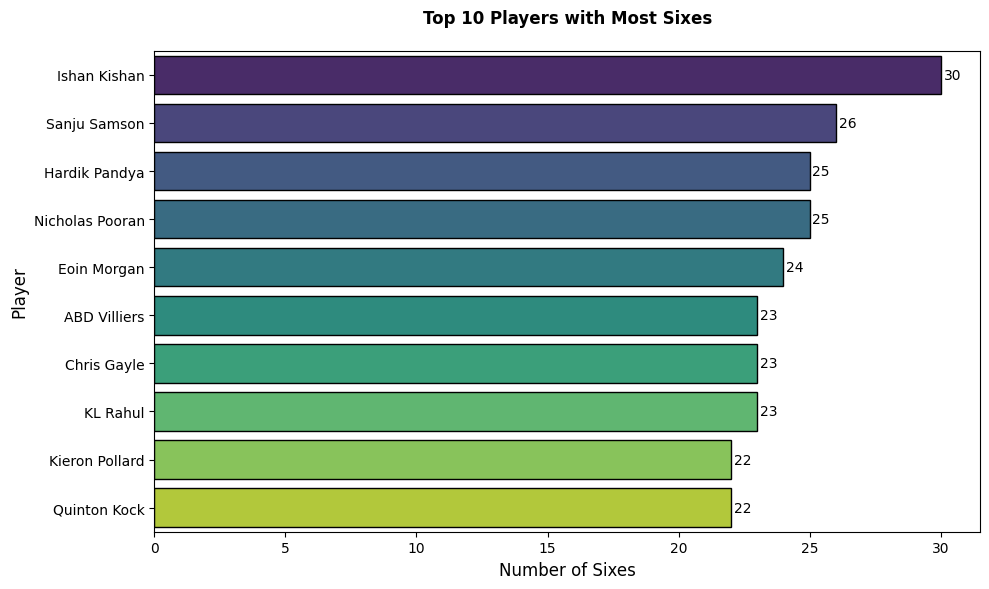

In [31]:
top_six_hitters = df.sort_values('6s', ascending=False).head(10)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    y='Player',
    x='6s',
    data=top_six_hitters,
    palette='viridis',
    edgecolor='black'
)

plt.title('Top 10 Players with Most Sixes', fontweight='bold', pad=20)
plt.xlabel('Number of Sixes', fontsize=12)
plt.ylabel('Player', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', padding=2)

plt.tight_layout()
plt.show()

# Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

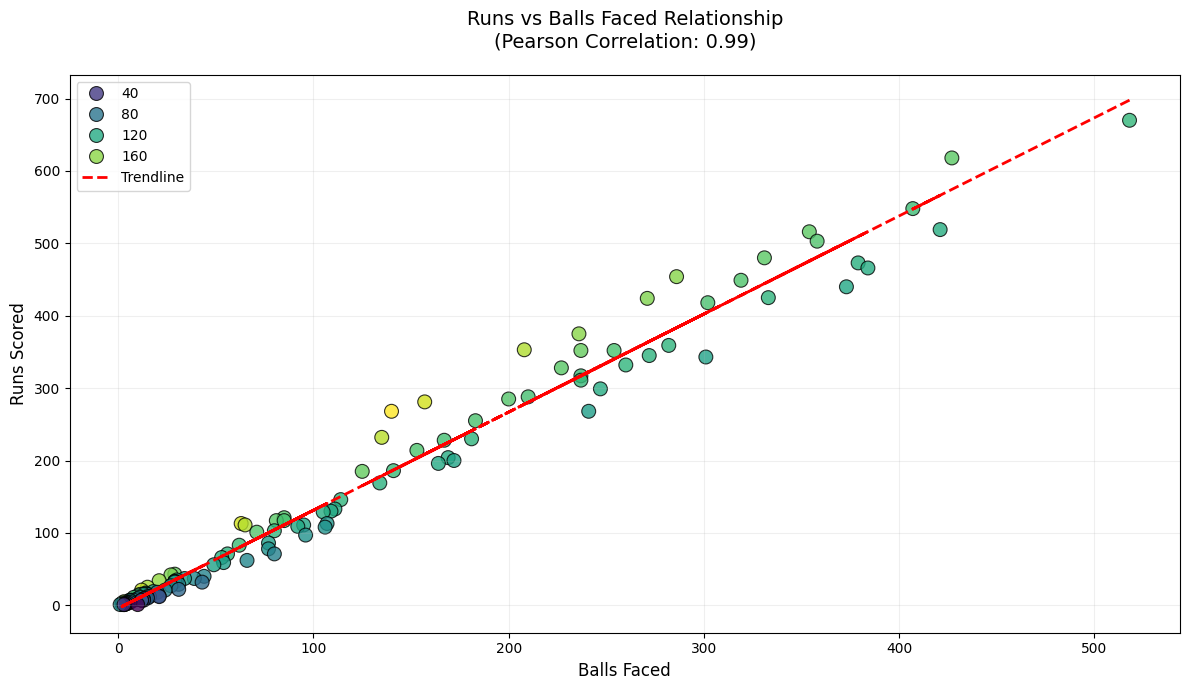

In [32]:
# Filter valid batting records (players who faced at least 1 ball)
valid_batters = df[(df['Balls faced'] > 0) & (df['Runs'] > 0)]

# Create scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Balls faced',
    y='Runs',
    data=valid_batters,
    hue='Strike rate',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

# Trendline
z = np.polyfit(valid_batters['Balls faced'], valid_batters['Runs'], 1)
p = np.poly1d(z)
plt.plot(valid_batters['Balls faced'], p(valid_batters['Balls faced']),
         "r--",
         linewidth=2,
         label='Trendline')

# Correlation coefficient
correlation = valid_batters[['Runs', 'Balls faced']].corr().iloc[0,1]

# Format plot
plt.title('Runs vs Balls Faced Relationship\n(Pearson Correlation: {:.2f})'.format(correlation),
          fontsize=14,
          pad=20)
plt.xlabel('Balls Faced', fontsize=12)
plt.ylabel('Runs Scored', fontsize=12)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()